In [1]:
# Import TensorFlow
import tensorflow as tf

# Import Keras layers and model utilities
from tensorflow.keras import layers, models

# NumPy for numerical operations
import numpy as np

# Matplotlib for displaying images and graphs
import matplotlib.pyplot as plt

# OS for working with folders and files
import os

# Print TensorFlow version
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Image height
IMG_HEIGHT = 128

# Image width
IMG_WIDTH = 128

# Number of image channels
# RGB image = 3 channels
IMG_CHANNELS = 3

# Number of images processed at once
BATCH_SIZE = 16

# Number of training epochs
EPOCHS = 10

print("Image size:", IMG_HEIGHT, "x", IMG_WIDTH)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

Image size: 128 x 128
Batch size: 16
Epochs: 10


In [3]:
# Download the Oxford-IIIT Pet images
!wget -q https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz

# Download the segmentation annotations
!wget -q https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


In [4]:
# Extract the image files
!tar -xzf images.tar.gz

# Extract the annotation files
!tar -xzf annotations.tar.gz

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [5]:
# Check whether the required folders exist
print("Images folder exists:", os.path.exists("images"))
print("Annotations folder exists:", os.path.exists("annotations"))

# Display a few image files
print("\nSample images:")
print(os.listdir("images")[:5])

# Display annotation folders
print("\nAnnotation folders:")
print(os.listdir("annotations"))

Images folder exists: True
Annotations folder exists: True

Sample images:
['Maine_Coon_78.jpg', 'newfoundland_192.jpg', 'shiba_inu_185.jpg', 'shiba_inu_97.jpg', 'pug_68.jpg']

Annotation folders:
['trimaps', 'xmls', '._trimaps', 'list.txt', 'test.txt', 'trainval.txt', 'README']


In [6]:
# Folder containing pet images
image_dir = "images"

# Folder containing segmentation masks
mask_dir = "annotations/trimaps"

# Get all JPEG image paths
image_paths = sorted([
    os.path.join(image_dir, file)
    for file in os.listdir(image_dir)
    if file.endswith(".jpg")
])

# Get all PNG mask paths
mask_paths = sorted([
    os.path.join(mask_dir, file)
    for file in os.listdir(mask_dir)
    if file.endswith(".png")
])

print("Number of images:", len(image_paths))
print("Number of masks:", len(mask_paths))

Number of images: 7390
Number of masks: 14780


In [7]:
# Create a dictionary containing mask paths
# The key is the filename without .png
mask_dict = {
    os.path.splitext(os.path.basename(path))[0]: path
    for path in mask_paths
}

# Lists for matched image-mask pairs
paired_images = []
paired_masks = []

# Go through every image
for image_path in image_paths:

    # Get image filename without .jpg
    image_name = os.path.splitext(
        os.path.basename(image_path)
    )[0]

    # Check if corresponding mask exists
    if image_name in mask_dict:

        paired_images.append(image_path)
        paired_masks.append(mask_dict[image_name])

print("Matched image-mask pairs:", len(paired_images))

Matched image-mask pairs: 7390


In [8]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split images and masks into training and testing data
train_img_paths, test_img_paths, train_mask_paths, test_mask_paths = train_test_split(
    paired_images,
    paired_masks,
    test_size=0.2,
    random_state=42
)

print("Training images:", len(train_img_paths))
print("Testing images:", len(test_img_paths))

Training images: 5912
Testing images: 1478


In [9]:
def load_image_and_mask(image_path, mask_path):

    # =========================
    # LOAD IMAGE
    # =========================

    # Read image file
    image = tf.io.read_file(image_path)

    # Decode JPEG image
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize image to 128 x 128
    image = tf.image.resize(
        image,
        (IMG_HEIGHT, IMG_WIDTH)
    )

    # Convert image pixels from [0,255] to [0,1]
    image = tf.cast(image, tf.float32) / 255.0


    # =========================
    # LOAD MASK
    # =========================

    # Read mask file
    mask = tf.io.read_file(mask_path)

    # Decode PNG mask
    mask = tf.image.decode_png(
        mask,
        channels=1
    )

    # Resize mask
    # nearest-neighbor keeps class labels intact
    mask = tf.image.resize(
        mask,
        (IMG_HEIGHT, IMG_WIDTH),
        method="nearest"
    )

    # Convert mask to integer
    mask = tf.cast(mask, tf.int32)

    # Oxford Pet trimap:
    # 1 = foreground
    # 2 = background
    # 3 = boundary
    #
    # Convert foreground to 1
    # Everything else to 0
    mask = tf.where(
        mask == 1,
        1,
        0
    )

    # Convert mask to float
    mask = tf.cast(mask, tf.float32)

    return image, mask

In [10]:
# =========================
# TRAINING DATASET
# =========================

# Create dataset from image and mask paths
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_img_paths, train_mask_paths)
)

# Apply preprocessing
train_dataset = train_dataset.map(
    load_image_and_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Shuffle training data
train_dataset = train_dataset.shuffle(500)

# Create batches
train_dataset = train_dataset.batch(BATCH_SIZE)

# Improve performance
train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)


# =========================
# TESTING DATASET
# =========================

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_img_paths, test_mask_paths)
)

# Apply preprocessing
test_dataset = test_dataset.map(
    load_image_and_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Create batches
test_dataset = test_dataset.batch(BATCH_SIZE)

# Improve performance
test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("Training and testing datasets created.")

Training and testing datasets created.


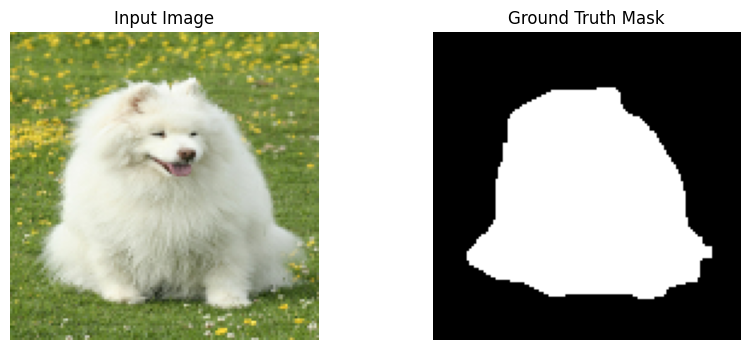

In [11]:
# Take one batch from the training dataset
sample_images, sample_masks = next(
    iter(train_dataset)
)

# Create figure
plt.figure(figsize=(10, 4))

# Display original image
plt.subplot(1, 2, 1)
plt.imshow(sample_images[0])
plt.title("Input Image")
plt.axis("off")

# Display ground-truth mask
plt.subplot(1, 2, 2)
plt.imshow(
    sample_masks[0].numpy().squeeze(),
    cmap="gray"
)
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

In [12]:
# Define a basic U-Net convolution block
def unet_block(x, filters):

    # First convolution
    c = layers.Conv2D(
        filters,
        (3, 3),
        activation="relu",
        padding="same"
    )(x)

    # Second convolution
    c = layers.Conv2D(
        filters,
        (3, 3),
        activation="relu",
        padding="same"
    )(c)

    return c

In [13]:
def build_unet(
    input_shape=(128, 128, 3),
    num_classes=1
):

    # =========================
    # INPUT
    # =========================

    inputs = layers.Input(
        shape=input_shape
    )


    # =========================
    # ENCODER
    # =========================

    # First encoder block
    c1 = unet_block(
        inputs,
        64
    )

    # Downsampling
    p1 = layers.MaxPooling2D(
        (2, 2)
    )(c1)


    # Second encoder block
    c2 = unet_block(
        p1,
        128
    )

    # Downsampling
    p2 = layers.MaxPooling2D(
        (2, 2)
    )(c2)


    # =========================
    # BOTTLENECK
    # =========================

    bn = unet_block(
        p2,
        256
    )


    # =========================
    # DECODER
    # =========================

    # First upsampling
    u1 = layers.UpSampling2D(
        (2, 2)
    )(bn)

    # Skip connection
    u1 = layers.Concatenate()(
        [u1, c2]
    )

    # Decoder block
    c3 = unet_block(
        u1,
        128
    )


    # Second upsampling
    u2 = layers.UpSampling2D(
        (2, 2)
    )(c3)

    # Skip connection
    u2 = layers.Concatenate()(
        [u2, c1]
    )

    # Decoder block
    c4 = unet_block(
        u2,
        64
    )


    # =========================
    # OUTPUT
    # =========================

    # 1x1 convolution produces
    # the final segmentation mask
    outputs = layers.Conv2D(
        num_classes,
        (1, 1),
        activation="sigmoid"
    )(c4)


    # Create complete model
    return models.Model(
        inputs,
        outputs
    )

In [14]:
# Build the U-Net model
model = build_unet(
    input_shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        IMG_CHANNELS
    ),
    num_classes=1
)

# Display model architecture
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_8[0][0]  

 Total params: 1,883,137 (7.18 MB)

 Trainable params: 1,883,137 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
def iou_metric(y_true, y_pred):

    # Convert predicted probabilities
    # into binary values
    y_pred = tf.cast(
        y_pred > 0.5,
        tf.float32
    )

    # Calculate intersection
    intersection = tf.reduce_sum(
        y_true * y_pred
    )

    # Calculate union
    union = (
        tf.reduce_sum(y_true)
        + tf.reduce_sum(y_pred)
        - intersection
    )

    # Calculate IoU
    iou = (
        intersection + 1e-7
    ) / (
        union + 1e-7
    )

    return iou

In [16]:
# Compile the U-Net model
model.compile(

    # Adam optimizer
    optimizer="adam",

    # Binary segmentation loss
    loss="binary_crossentropy",

    # Required evaluation metrics
    metrics=[
        "accuracy",
        iou_metric
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [17]:
# Train the U-Net model
history = model.fit(

    # Training dataset
    train_dataset,

    # Number of epochs
    epochs=EPOCHS,

    # Use test dataset for validation
    validation_data=test_dataset
)

Epoch 1/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 102s 204ms/step - accuracy: 0.7352 - iou_metric: 0.3099 - loss: 0.4944 - val_accuracy: 0.7611 - val_iou_metric: 0.3814 - val_loss: 0.4554
Epoch 2/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 57s 151ms/step - accuracy: 0.7785 - iou_metric: 0.4367 - loss: 0.4432 - val_accuracy: 0.7915 - val_iou_metric: 0.4777 - val_loss: 0.4666
Epoch 3/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 57s 150ms/step - accuracy: 0.8241 - iou_metric: 0.5312 - loss: 0.3845 - val_accuracy: 0.8322 - val_iou_metric: 0.5937 - val_loss: 0.3653
Epoch 4/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 57s 150ms/step - accuracy: 0.8536 - iou_metric: 0.5989 - loss: 0.3319 - val_accuracy: 0.8650 - val_iou_metric: 0.6011 - val_loss: 0.3115
Epoch 5/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 57s 152ms/step - accuracy: 0.8712 - iou_metric: 0.6409 - loss: 0.2979 - val_accuracy: 0.8685 - val_iou_metric: 0.6632 - val_loss: 0.3051
Epoch 6/10
370/370 ━━━━━━━━━━━━━━━━━━━━ 58s 152ms/step - accuracy: 0.8820 - iou_metric: 0.6672 - loss: 0.2751 - va

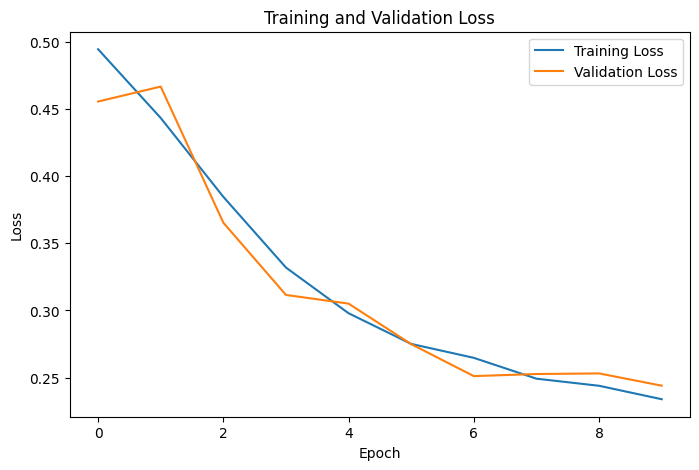

In [18]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.show()

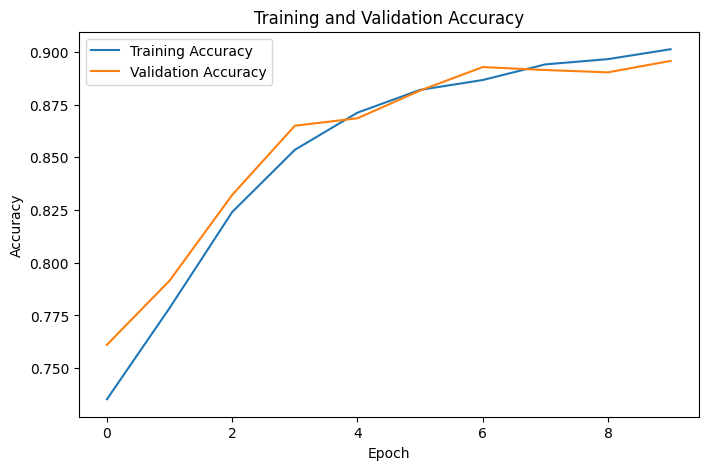

In [19]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.show()

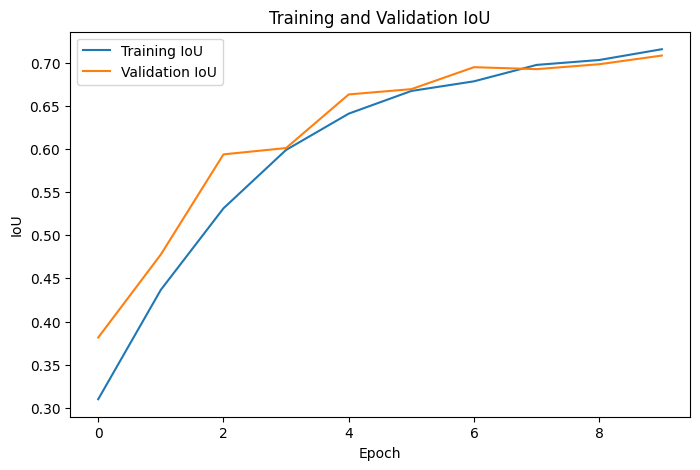

In [20]:
# Plot training and validation IoU

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["iou_metric"],
    label="Training IoU"
)

plt.plot(
    history.history["val_iou_metric"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")

plt.title(
    "Training and Validation IoU"
)

plt.legend()

plt.show()

In [21]:
# Evaluate the trained model
# on the test dataset

results = model.evaluate(
    test_dataset
)

print("\nTest Results:")

# Print each metric
for name, value in zip(
    model.metrics_names,
    results
):
    print(
        name,
        ":",
        value
    )

93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8958 - iou_metric: 0.7083 - loss: 0.2440

Test Results:
loss : 0.24402031302452087
compile_metrics : 0.8957676291465759


In [22]:
# Get one batch of test images and masks
test_images_batch, test_masks_batch = next(
    iter(test_dataset)
)

# Generate predictions
predicted_masks = model.predict(
    test_images_batch
)

print("Predictions generated.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step
Predictions generated.


In [23]:
# Convert predicted probabilities
# into binary segmentation masks

binary_predictions = (
    predicted_masks > 0.5
).astype(np.float32)

print("Binary predicted masks created.")

Binary predicted masks created.


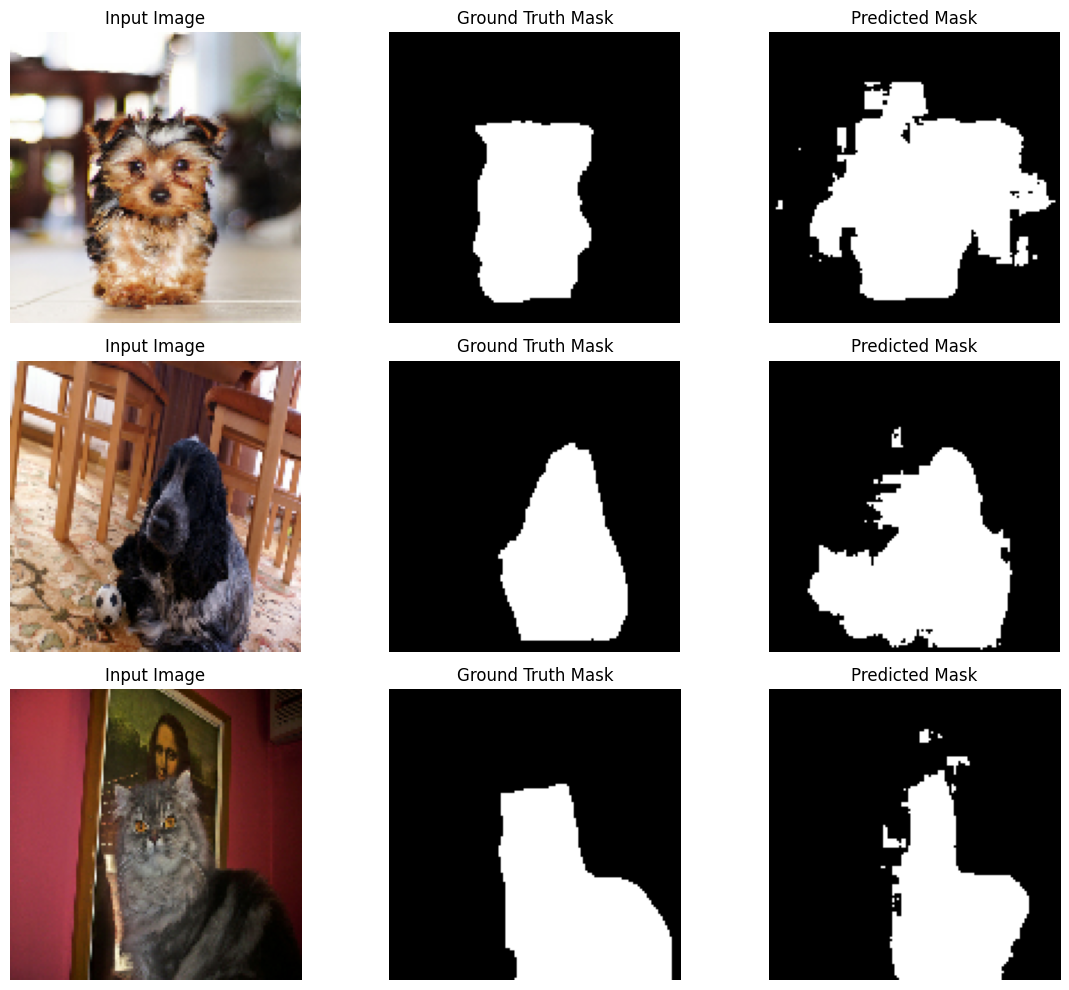

In [24]:
# Number of images to display
num_examples = 3

# Create figure
plt.figure(
    figsize=(12, 10)
)

for i in range(num_examples):

    # =========================
    # ORIGINAL IMAGE
    # =========================

    plt.subplot(
        num_examples,
        3,
        i * 3 + 1
    )

    plt.imshow(
        test_images_batch[i]
    )

    plt.title("Input Image")
    plt.axis("off")


    # =========================
    # TRUE MASK
    # =========================

    plt.subplot(
        num_examples,
        3,
        i * 3 + 2
    )

    plt.imshow(
        test_masks_batch[i]
        .numpy()
        .squeeze(),
        cmap="gray"
    )

    plt.title("Ground Truth Mask")
    plt.axis("off")


    # =========================
    # PREDICTED MASK
    # =========================

    plt.subplot(
        num_examples,
        3,
        i * 3 + 3
    )

    plt.imshow(
        binary_predictions[i]
        .squeeze(),
        cmap="gray"
    )

    plt.title("Predicted Mask")
    plt.axis("off")


# Adjust spacing
plt.tight_layout()

# Display everything
plt.show()

In [25]:
# Save the trained U-Net model
model.save(
    "unet_oxford_pet.keras"
)

print(
    "Model saved as unet_oxford_pet.keras"
)

Model saved as unet_oxford_pet.keras
